# CMAPSS FD001 — RUL forecasting

## Objectives

- build baseline RUL forecasting models
- compare classical ML and DL approaches
- evaluate predictive performance
- identify the best-performing model

## Environment and Library Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import sys
sys.path.append("..")
from src.RUL_forecasting import (evaluate, nasa_score, make_sequences,
                                 build_lstm, build_bilstm)

import joblib

import warnings
warnings.filterwarnings('ignore')

## Load data

In [6]:
data_path = "../data/processed/"

In [7]:
train_df = pd.read_parquet(os.path.join(data_path, "rul_train.parquet"))
print(train_df.shape)
print(train_df.columns)

(16020, 81)
Index(['engine_id', 'cycle', 'RUL', 'sensor_2', 'sensor_3', 'sensor_4',
       'sensor_7', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13',
       'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21',
       'sensor_2_rolling_mean', 'sensor_2_rolling_std',
       'sensor_3_rolling_mean', 'sensor_3_rolling_std',
       'sensor_4_rolling_mean', 'sensor_4_rolling_std',
       'sensor_7_rolling_mean', 'sensor_7_rolling_std',
       'sensor_9_rolling_mean', 'sensor_9_rolling_std',
       'sensor_11_rolling_mean', 'sensor_11_rolling_std',
       'sensor_12_rolling_mean', 'sensor_12_rolling_std',
       'sensor_13_rolling_mean', 'sensor_13_rolling_std',
       'sensor_14_rolling_mean', 'sensor_14_rolling_std',
       'sensor_15_rolling_mean', 'sensor_15_rolling_std',
       'sensor_17_rolling_mean', 'sensor_17_rolling_std',
       'sensor_20_rolling_mean', 'sensor_20_rolling_std',
       'sensor_21_rolling_mean', 'sensor_21_rolling_std', 'sensor_2_lag_1',
       'sens

In [8]:
val_df = pd.read_parquet(os.path.join(data_path, "rul_val.parquet"))
print(val_df.shape)
print(val_df.columns)

(4211, 81)
Index(['engine_id', 'cycle', 'RUL', 'sensor_2', 'sensor_3', 'sensor_4',
       'sensor_7', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13',
       'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21',
       'sensor_2_rolling_mean', 'sensor_2_rolling_std',
       'sensor_3_rolling_mean', 'sensor_3_rolling_std',
       'sensor_4_rolling_mean', 'sensor_4_rolling_std',
       'sensor_7_rolling_mean', 'sensor_7_rolling_std',
       'sensor_9_rolling_mean', 'sensor_9_rolling_std',
       'sensor_11_rolling_mean', 'sensor_11_rolling_std',
       'sensor_12_rolling_mean', 'sensor_12_rolling_std',
       'sensor_13_rolling_mean', 'sensor_13_rolling_std',
       'sensor_14_rolling_mean', 'sensor_14_rolling_std',
       'sensor_15_rolling_mean', 'sensor_15_rolling_std',
       'sensor_17_rolling_mean', 'sensor_17_rolling_std',
       'sensor_20_rolling_mean', 'sensor_20_rolling_std',
       'sensor_21_rolling_mean', 'sensor_21_rolling_std', 'sensor_2_lag_1',
       'senso

## Define features & target

The processed dataset already contains all engineered features from notebook 02:
raw sensor readings, rolling statistics (mean & std), and lag features.

`engine_id` and `cycle` are dropped as identifiers.  
`RUL` is the regression target.

In [9]:
TARGET = 'RUL'
DROP   = ['engine_id', 'cycle', 'RUL']
FEATURES = [col for col in train_df.columns if col not in DROP]

In [10]:
X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_val   = val_df[FEATURES]
y_val   = val_df[TARGET]

In [13]:
print(f"Features : {len(FEATURES)}")
print(f"X_train : {X_train.shape}")
print(f"X_val : {X_val.shape}")
print()
print(FEATURES)

Features : 78
X_train : (16020, 78)
X_val : (4211, 78)

['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'sensor_2_rolling_mean', 'sensor_2_rolling_std', 'sensor_3_rolling_mean', 'sensor_3_rolling_std', 'sensor_4_rolling_mean', 'sensor_4_rolling_std', 'sensor_7_rolling_mean', 'sensor_7_rolling_std', 'sensor_9_rolling_mean', 'sensor_9_rolling_std', 'sensor_11_rolling_mean', 'sensor_11_rolling_std', 'sensor_12_rolling_mean', 'sensor_12_rolling_std', 'sensor_13_rolling_mean', 'sensor_13_rolling_std', 'sensor_14_rolling_mean', 'sensor_14_rolling_std', 'sensor_15_rolling_mean', 'sensor_15_rolling_std', 'sensor_17_rolling_mean', 'sensor_17_rolling_std', 'sensor_20_rolling_mean', 'sensor_20_rolling_std', 'sensor_21_rolling_mean', 'sensor_21_rolling_std', 'sensor_2_lag_1', 'sensor_2_lag_2', 'sensor_2_lag_3', 'sensor_3_lag_1', 'sensor_3_lag_2', 'sensor_3_lag_3', 'sensor_4_lag_1', 

## Evaluation metrics (RMSE, MAE, R², NASA score)

Models are evaluated with four metrics:

- **RMSE** — penalises large errors more than MAE
- **MAE** — average absolute error in cycles
- **R²** — proportion of variance explained
- **NASA Score** — asymmetric scoring function from the original CMAPSS paper:
$$s = \sum_{i=1}^{N} \begin{cases} e^{-d/13} - 1 & \text{if } d < 0 \\ e^{d/10} - 1 & \text{if } d \geq 0 \end{cases}$$
 where $d = \hat{RUL} - RUL_{true}$.  
Late predictions ($d > 0$, underestimating RUL) are penalised with base 10, early predictions ($d < 0$, overestimating RUL) with base 13 — reflecting the higher operational cost of unexpected failures vs unnecessary maintenance interventions.  
Lower is better; the score has no absolute reference and should be interpreted relatively across models.

In [14]:
results = {}

## Baseline model (Mean predictor, Linear Regression)


Two simple baselines establish the minimum performance bar:

- **Mean Predictor** — always predicts the mean RUL of the training set. Any useful model must beat this.
- **Linear Regression** — simplest parametric model, assumes a linear relationship between features and RUL.

In [15]:
# Mean Predictor
mean_pred = np.full(len(y_val), y_train.mean())
evaluate('Mean Predictor', y_val, mean_pred, results);

Mean Predictor            RMSE=41.64  MAE=37.19  R²=-0.002  NASA=1140682.3


In [16]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [17]:
evaluate('Linear Regression', y_val, lr.predict(X_val), results);

Linear Regression         RMSE=21.09  MAE=17.69  R²=0.743  NASA=42042.0


## Classical ML (Random Forest, XGBoost)


Tree-based models that handle non-linearity and feature interactions without requiring manual feature engineering.

- **Random Forest** — ensemble of decorrelated decision trees, robust to overfitting thanks to bagging.
- **XGBoost** — gradient boosting with regularisation, typically the strongest classical ML model on tabular data.

Hyperparameters tuned via 3-fold cross-validation on the training set using RandomizedSearchCV with n_iter=20.

### Random Forest

In [18]:
rf_params = {'n_estimators': [100, 200, 300],
             'max_depth': [6, 10, 15, None],
             'min_samples_split': [2, 5, 10],
             'max_features': ['sqrt', 'log2']}

In [19]:
rf = RandomizedSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                        rf_params,
                        n_iter=20,
                        cv=3,
                        scoring='neg_root_mean_squared_error',
                        random_state=42,
                        n_jobs=-1,
                        verbose=0)

In [20]:
rf.fit(X_train, y_train)
print(f"RF  best params : {rf.best_params_}")

RF  best params : {'n_estimators': 200, 'min_samples_split': 10, 'max_features': 'log2', 'max_depth': 10}


In [21]:
evaluate('Random Forest', y_val, rf.best_estimator_.predict(X_val), results);

Random Forest             RMSE=19.29  MAE=13.96  R²=0.785  NASA=76501.3


### XGBoost

In [22]:
xgb_params = {'n_estimators': [100, 200, 300],
              'max_depth': [3, 5, 7],
              'learning_rate': [0.01, 0.05, 0.1],
              'subsample': [0.7, 0.8, 1.0],
              'colsample_bytree': [0.7, 0.8, 1.0]}

In [23]:
xgb_model = RandomizedSearchCV(xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
                               xgb_params,
                               n_iter=20,
                               cv=3,
                               scoring='neg_root_mean_squared_error',
                               random_state=42,
                               n_jobs=-1,
                               verbose=0)

In [24]:
xgb_model.fit(X_train, y_train)
print(f"XGB best params : {xgb_model.best_params_}")

XGB best params : {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


In [25]:
evaluate('XGBoost', y_val, xgb_model.best_estimator_.predict(X_val), results);

XGBoost                   RMSE=19.56  MAE=14.57  R²=0.779  NASA=78822.1


## Sequence preparation (sliding window per LSTM)

LSTM models require 3D input of shape `(samples, timesteps, features)`.

A sliding window of length `SEQ_LEN = 30` is built **per engine** to preserve temporal order and avoid mixing cycles from different engines.

For the sequence features only the **all selected sensors** are used — rolling and lag features are redundant here since the LSTM learns temporal dependencies directly from the sequence.

In [26]:
SEQ_LEN = 30
SEQ_SENSORS = [col for col in train_df.columns
               if col.startswith('sensor')
               and '_rolling' not in col
               and '_lag' not in col]

In [27]:
X_train_seq, y_train_seq = make_sequences(train_df, SEQ_SENSORS, 'RUL', SEQ_LEN)
X_val_seq, y_val_seq = make_sequences(val_df,   SEQ_SENSORS, 'RUL', SEQ_LEN)

In [28]:
print(f"X_train_seq : {X_train_seq.shape}  → (samples, timesteps, features)")
print(f"X_val_seq : {X_val_seq.shape}")

X_train_seq : (13700, 30, 13)  → (samples, timesteps, features)
X_val_seq : (3631, 30, 13)


## Deep Learning (LSTM, Bidirectional LSTM)


Both models share the same architecture pattern — two recurrent layers with dropout and a dense head — differing only in the use of bidirectionality.

- **LSTM** — processes the sequence forward, capturing degradation trends over time.
- **Bidirectional LSTM** — processes the sequence in both directions, giving each   timestep context from past and future cycles within the window.

Early stopping on validation loss prevents overfitting.

In [29]:
INPUT_SHAPE = (SEQ_LEN, len(SEQ_SENSORS))

In [40]:
callbacks = [EarlyStopping(monitor='val_loss',
                           patience=15,
                           restore_best_weights=True,
                           verbose=1),
             ReduceLROnPlateau(monitor='val_loss',
                               factor=0.5,
                               patience=7,
                               min_lr=1e-6,
                               verbose=1)]

### LSTM

In [41]:
EPOCHS = 100
BATCH  = 256

In [42]:
lstm   = build_lstm(INPUT_SHAPE)

In [43]:
lstm.summary()

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 128)        │        72,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,225 (485.25 KB)

 Trainable params: 124,225 (485.25 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
history_lstm = lstm.fit(X_train_seq,
                        y_train_seq,
                        validation_data=(X_val_seq, y_val_seq),
                        epochs=EPOCHS,
                        batch_size=BATCH,
                        callbacks=callbacks,
                        verbose=1)

Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 6982.8198 - mae: 73.1107 - val_loss: 6258.8081 - val_mae: 68.4042 - learning_rate: 0.0010
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4921.2363 - mae: 59.4474 - val_loss: 4098.8584 - val_mae: 54.4018 - learning_rate: 0.0010
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2885.1770 - mae: 44.0248 - val_loss: 2121.3701 - val_mae: 37.8798 - learning_rate: 0.0010
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1408.9963 - mae: 30.2014 - val_loss: 977.6687 - val_mae: 25.7106 - learning_rate: 0.0010
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 638.4342 - mae: 20.1487 - val_loss: 438.2477 - val_mae: 17.5628 - learning_rate: 0.0010
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 325.3080 - mae: 14.4592 - val_loss: 279.8713 - val_mae: 14.1124 - learning_rate: 0.0010
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 222.2073 - mae: 11.5611 - val_loss: 209.2934 

In [50]:
evaluate('LSTM', y_val_seq, lstm.predict(X_val_seq).flatten(), results);

114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
LSTM                      RMSE=13.38  MAE=9.50  R²=0.898  NASA=12179.4


#### Learning Curve

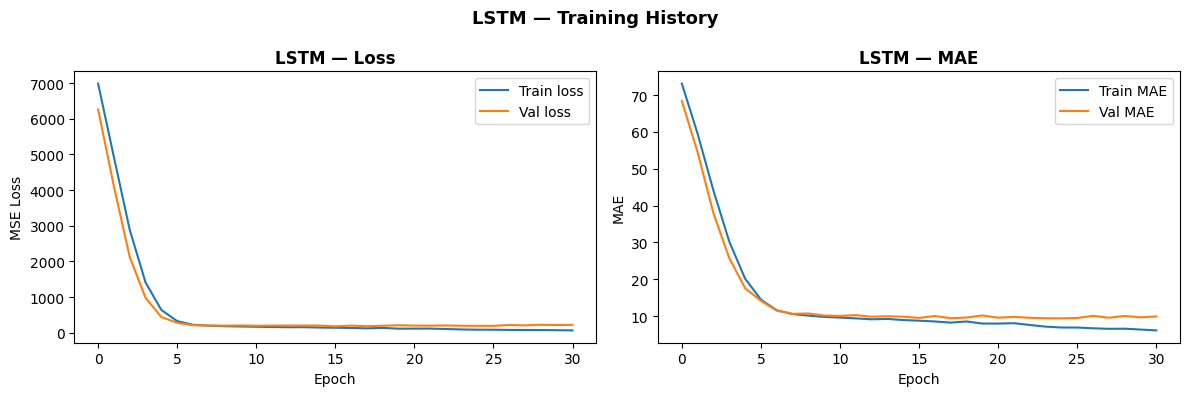

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history_lstm.history['loss'], label='Train loss')
axes[0].plot(history_lstm.history['val_loss'], label='Val loss')
axes[0].set_title('LSTM — Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

# MAE
axes[1].plot(history_lstm.history['mae'], label='Train MAE')
axes[1].plot(history_lstm.history['val_mae'], label='Val MAE')
axes[1].set_title('LSTM — MAE', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.suptitle('LSTM — Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/03_lstm_training_history.png', bbox_inches='tight')
plt.show()

**Observations:**
- Both loss and MAE converge rapidly in the first 5 epochs, then stabilize — the model learns the main degradation pattern quickly
- Train and val curves track closely throughout, indicating no significant overfitting
- A small gap between train and val MAE opens after epoch 15, suggesting the model begins to slightly overfit in the later epochs — early stopping correctly intervenes around epoch 30
- The smooth convergence confirms the architecture is well-suited to this dataset size

### Bidirectional LSTM

In [45]:
bilstm = build_bilstm(INPUT_SHAPE)

In [46]:
bilstm.summary()

Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 30, 256)        │       145,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 313,921 (1.20 MB)

 Trainable params: 313,921 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
history_bilstm = bilstm.fit(X_train_seq,
                            y_train_seq,
                            validation_data=(X_val_seq, y_val_seq),
                            epochs=EPOCHS,
                            batch_size=BATCH,
                            callbacks=callbacks,
                            verbose=1)

Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 5113.4868 - mae: 60.8268 - val_loss: 2572.6565 - val_mae: 42.4918 - learning_rate: 0.0010
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1246.3094 - mae: 28.5860 - val_loss: 706.4221 - val_mae: 22.4335 - learning_rate: 0.0010
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 498.2158 - mae: 18.2353 - val_loss: 367.7578 - val_mae: 15.9825 - learning_rate: 0.0010
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 266.7115 - mae: 12.9409 - val_loss: 268.4103 - val_mae: 12.9875 - learning_rate: 0.0010
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 210.5286 - mae: 10.9908 - val_loss: 250.9533 - val_mae: 11.5379 - learning_rate: 0.0010
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 193.1406 - mae: 10.4212 - val_loss: 230.3621 - val_mae: 11.2321 - learning_rate: 0.0010
Epoch 7/100
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 172.0716 - mae: 9.7395
Epoch 7: ReduceLROnPlateau

In [49]:
evaluate('BiLSTM', y_val_seq, bilstm.predict(X_val_seq).flatten(), results);

114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
BiLSTM                    RMSE=50.72  MAE=42.49  R²=-0.471  NASA=429678.8


#### Learning Curve

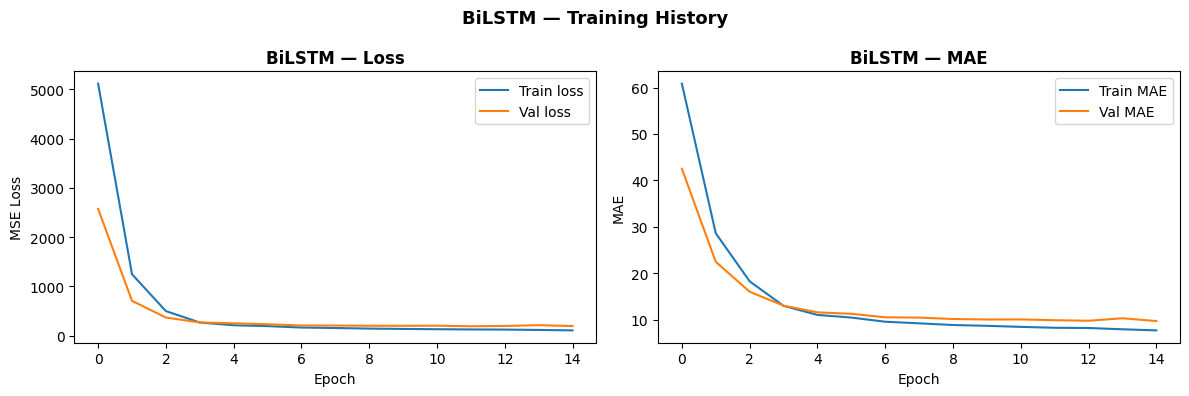

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history_bilstm.history['loss'], label='Train loss')
axes[0].plot(history_bilstm.history['val_loss'], label='Val loss')
axes[0].set_title('BiLSTM — Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

# MAE
axes[1].plot(history_bilstm.history['mae'], label='Train MAE')
axes[1].plot(history_bilstm.history['val_mae'], label='Val MAE')
axes[1].set_title('BiLSTM — MAE', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.suptitle('BiLSTM — Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/03_bilstm_training_history.png', bbox_inches='tight')
plt.show()

**Observations:**
- Train and val curves converge smoothly — no visible divergence or instability during training
- Unusually, val_loss remains consistently below train_loss throughout — suggesting the validation engines have more regular degradation patterns than the training set
- Despite apparent convergence, the model achieves RMSE=50.72 and R²=-0.471 — significantly worse than the Mean Predictor
- The smooth convergence despite poor final performance suggests the model converges to a suboptimal solution rather than overfitting — likely a consequence of restore_best_weights restoring epoch 1 initialisation as the global optimum.

## Model comparison (tabella + grafico)


Summary of all models evaluated on the validation set.  

Lower RMSE and NASA Score are better; higher R² is better.

In [51]:
results_df = (pd.DataFrame(results).T.sort_values('RMSE').round(3))
display(results_df)

,RMSE,MAE,R²,NASA Score
LSTM,13.383,9.495,0.898,12179.376
Random Forest,19.291,13.959,0.785,76501.259
XGBoost,19.559,14.572,0.779,78822.138
Linear Regression,21.093,17.688,0.743,42041.962
Mean Predictor,41.642,37.193,-0.002,1140682.332
BiLSTM,50.721,42.492,-0.471,429678.780


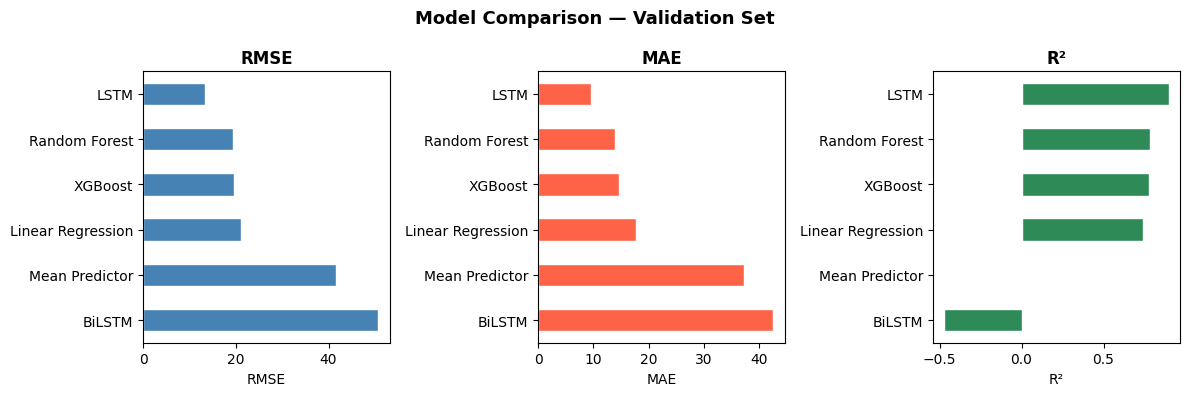

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
metrics   = ['RMSE', 'MAE', 'R²']
colors    = ['steelblue', 'tomato', 'seagreen']

for ax, metric, color in zip(axes, metrics, colors):
    results_df[metric].plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel(metric)
    ax.invert_yaxis()

plt.suptitle('Model Comparison — Validation Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/03_model_comparison.png', bbox_inches='tight')
plt.show()

### Results

LSTM is the best performing model (RMSE=13.38, R²=0.898), outperforming all other approaches by a significant margin.

Random Forest (RMSE=19.29, R²=0.785) and XGBoost (RMSE=19.56, R²=0.779) are closely clustered, suggesting that the engineered features — rolling statistics and lag features — already capture most of the temporal information available to tabular models.

Linear Regression (RMSE=21.09, R²=0.743) performs competitively, confirming that the relationship between the engineered features and the capped RUL is largely linear.

The NASA Score confirms LSTM as the best model: with a score of 12179
it achieves 3× lower penalty than Linear Regression (42042), 6× lower than Random Forest (76501), and 35× lower than BiLSTM (429678) — reflecting its superiority particularly in avoiding late predictions that could lead to unexpected failures.

**BiLSTM** fails to generalise on FD001 for three compounding reasons:
- **Over-parameterisation**: 313K parameters vs 124K of the LSTM —   insufficient data to train a bidirectional architecture on 100 engines
- **Training instability**: `restore_best_weights=True` consistently restores epoch 1 weights — the random initialisation produces a spuriously low val_loss before learning begins, which early stopping treats as the global optimum, preventing convergence
- **Bidirectionality not physically motivated**: in a degradation setting, future cycles within the window carry no additional causal information — processing sequences backwards adds complexity without justification

The NASA Score confirms LSTM as the best model across all metrics.



> Note: tree-based models are evaluated on the full validation set (4211 samples), while LSTM and BiLSTM are evaluated on sequences of length 30 (3631 samples).  
Direct metric comparison should be interpreted with this in mind.

## Error & residual analysis


A deeper look at the best model (LSTM) to understand where and how it fails.

- **Predicted vs Actual** — how closely predictions follow the ideal line
- **Residual distribution** — whether errors are symmetric and centered on zero
- **Residuals vs RUL** — whether errors are uniform across the degradation curve or concentrated in specific phases (early life vs near failure)

In [55]:
best_preds = lstm.predict(X_val_seq).flatten()

114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [56]:
residuals  = y_val_seq - best_preds

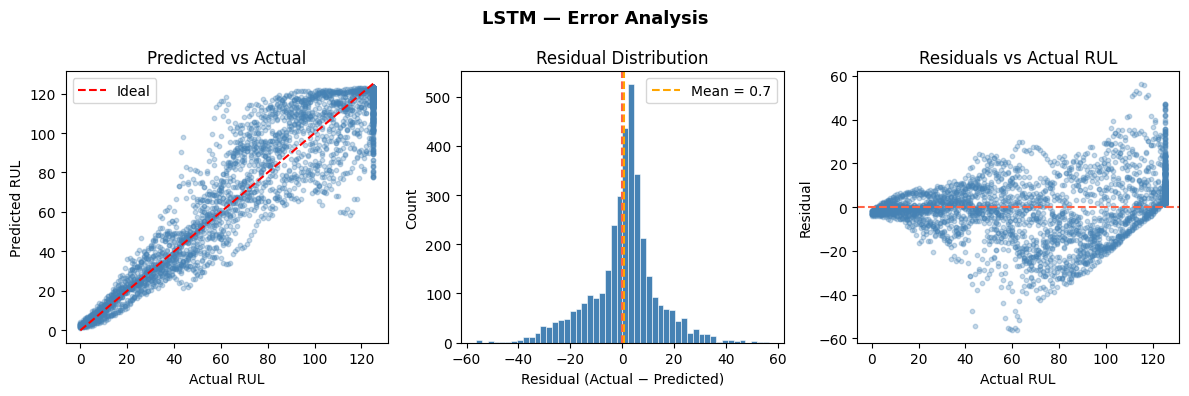

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Predicted vs Actual
axes[0].scatter(y_val_seq, best_preds, alpha=0.3, s=10, color='steelblue')
lims = [0, y_val_seq.max()]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Ideal')
axes[0].set_xlabel('Actual RUL')
axes[0].set_ylabel('Predicted RUL')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()

# Residual distribution
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
axes[1].axvline(0, color='tomato', linestyle='--', linewidth=1.5)
axes[1].axvline(residuals.mean(), color='orange', linestyle='--',
                linewidth=1.5, label=f'Mean = {residuals.mean():.1f}')
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')
axes[1].legend()

# Residuals vs Actual RUL
axes[2].scatter(y_val_seq, residuals, alpha=0.3, s=10, color='steelblue')
axes[2].axhline(0, color='tomato', linestyle='--', linewidth=1.5)
axes[2].set_xlabel('Actual RUL')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs Actual RUL')

plt.suptitle('LSTM — Error Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/03_error_analysis.png', bbox_inches='tight')
plt.show()

####Observations

**Predicted vs Actual** — the model tracks the ideal line closely across the entire RUL range [0, 125].  
The model generalises well throughout the full degradation window thanks to the RUL cap applied during training.

**Residual Distribution** — symmetric and centered at 0.7, confirming the model is essentially unbiased.  
The distribution is narrow and concentrated around zero, consistent with the low MAE=9.5.

**Residuals vs Actual RUL** — residuals are close to zero and uniform for RUL < 80, where prediction matters most for maintenance decisions.  
Variance increases near RUL=125 — the cap boundary creates a cluster of points where the model must predict the same target value (125) from diverse sensor trajectories, naturally increasing error variability.

## Feature importance (RF + XGBoost)

Feature importance is extracted from the two best classical ML models:
- **Random Forest** (impurity-based)
- **XGBoost** (gain-based).

Neural networks are excluded as their internal representations are not directly interpretable in this way.

In [58]:
importance_rf  = pd.Series(rf.best_estimator_.feature_importances_,
                           index=FEATURES)
importance_xgb = pd.Series(xgb_model.best_estimator_.feature_importances_,
                           index=FEATURES)

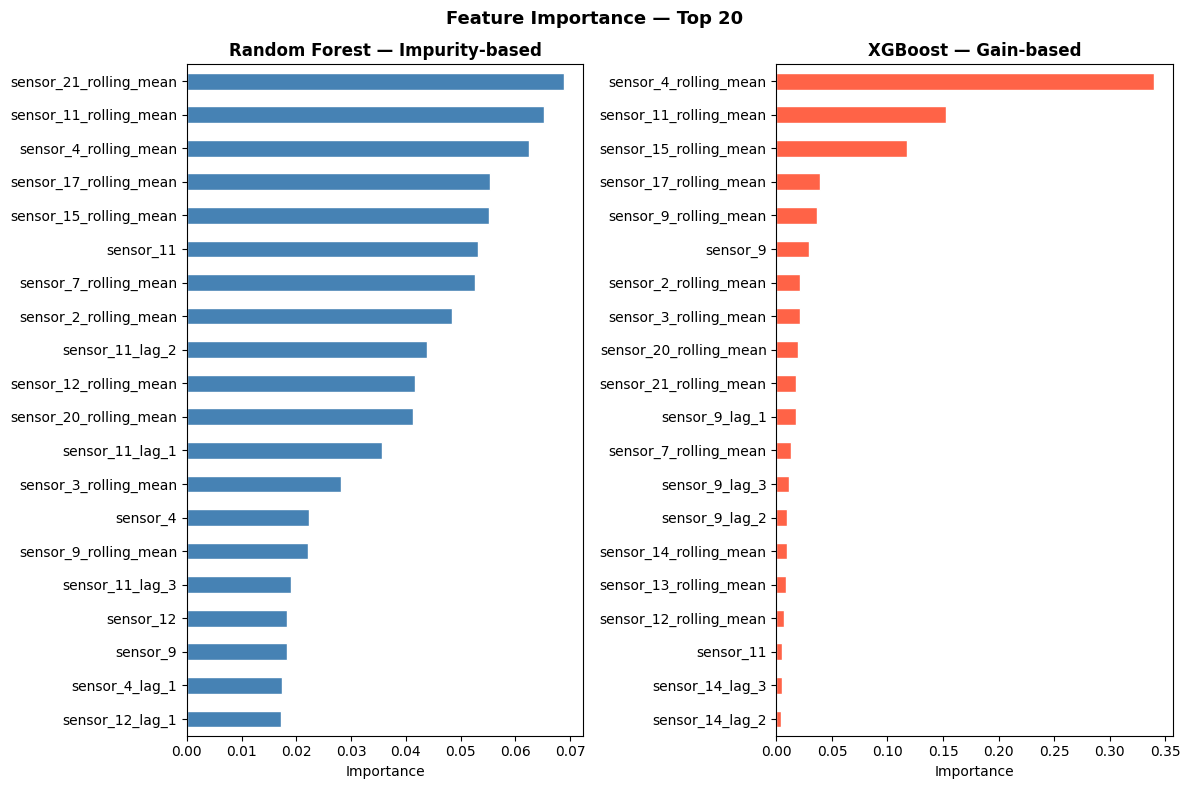

In [62]:
top_n = 20
fig, axes = plt.subplots(1, 2, figsize=(12, 8))

for ax, importance, title, color in zip(axes,
                                        [importance_rf, importance_xgb],
                                        ['Random Forest — Impurity-based', 'XGBoost — Gain-based'],
                                        ['steelblue', 'tomato']):
    importance.sort_values().tail(top_n).plot(kind='barh',
                                              ax=ax,
                                              color=color,
                                              edgecolor='white')
    ax.set_title(title,
                 fontweight='bold')
    ax.set_xlabel('Importance')

plt.suptitle(f'Feature Importance — Top {top_n}',
             fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/03_feature_importance.png', bbox_inches='tight')
plt.show()

#### Observations

Both models confirm **rolling means as the dominant feature group** — smoothed sensor trends carry far more predictive signal than instantaneous readings, lag features, or rolling std.

**RF and XGBoost agree on the top features** but with different concentration: XGBoost assigns ~35% of importance to `sensor_4_rolling_mean` alone, while RF distributes importance more evenly across the top 20 features — a known difference between gain-based and impurity-based importance metrics.

**sensor_4, sensor_11, sensor_21 rolling means** appear in the top 5 of both models, confirming these as the most informative degradation signals — consistent with the EDA findings.

**Lag features** appear only in the RF top 20 (sensor_11_lag_1/2/3), and are largely absent from XGBoost — suggesting lag information is partially redundant with the rolling mean for gradient boosting.

**Rolling std features** are absent from both top 20 lists, confirming the EDA observation that sensor volatility is not a strong predictor of RUL on FD001.

## Save best model

The LSTM is saved in native Keras format for later use in the pipeline as the best performing model (RMSE=13.38, R²=0.898).

Feature lists are serialised for consistent inference in downstream notebooks. The results table is exported as CSV for reference.

In [63]:
lstm.save('../outputs/RUL_forecasting_model/lstm_rul_fd001.keras')
print('Saved: ../outputs/RUL_forecasting_model/lstm_rul_fd001.keras')

Saved: ../outputs/RUL_forecasting_model/lstm_rul_fd001.keras


In [64]:
results_df.to_csv('../outputs/RUL_forecasting_model/rul_model_results.csv')
joblib.dump(FEATURES, '../outputs/RUL_forecasting_model/features.pkl')
joblib.dump(SEQ_SENSORS, '../outputs/RUL_forecasting_model/seq_sensors.pkl')
print('Saved: ../outputs/RUL_forecasting_model/rul_model_results.csv')
print('Saved: ../outputs/RUL_forecasting_model/features.pkl')
print('Saved: ../outputs/RUL_forecasting_model/seq_sensors.pkl')

Saved: ../outputs/RUL_forecasting_model/rul_model_results.csv
Saved: ../outputs/RUL_forecasting_model/features.pkl
Saved: ../outputs/RUL_forecasting_model/seq_sensors.pkl
